<a href="https://colab.research.google.com/github/elsolimecanico/Reconstrucci-n-de-Campos-de-Flujo-con-Super-Resoluci-n-mediante-CNNs-con-F-sica-Incorporada/blob/main/fase3_perdida_fisica_divergencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 3 — Penalización Física por Divergencia (PINN ligero)

**Resultado de la Fase 2 (referencia):** Error L2 relativo CNN = 0.0213, vs. bicúbico = 0.2202 (mejora de 90.3%).

**Objetivo de esta fase:** el modelo de la Fase 2 solo aprendió a minimizar el error pixel a pixel (MSE). No sabe nada de física -- no hay garantía de que el campo reconstruido sea físicamente consistente. Para un flujo incompresible 2D, la física exige:

$$ \nabla \cdot \mathbf{u} = \frac{\partial u_x}{\partial x} + \frac{\partial u_y}{\partial y} = 0 $$

Vamos a añadir esto como un **término extra de pérdida** (no vamos a resolver Navier-Stokes dentro de la red -- eso sería un PINN completo, mucho más caro de entrenar). Es un PINN ligero: se calcula la divergencia del campo reconstruido con diferencias finitas, y se penaliza cuando no es cercana a cero.

**Loss combinada:**
$$ \mathcal{L} = \mathcal{L}_{MSE} + \lambda \cdot \mathcal{L}_{div}, \quad \mathcal{L}_{div} = \text{mean}\left[(\nabla \cdot \mathbf{u}_{pred})^2\right] $$

**Hipótesis a probar:** el error L2 relativo puede no mejorar mucho (o incluso empeorar levemente), pero el campo debería ser más consistente físicamente -- por eso vamos a medir *ambas* cosas: error L2 Y magnitud de divergencia, no solo una.

## 1. Cargar dataset y el modelo de la Fase 2 (para comparar)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Corre esto en tu Colab para ubicar el .pt real
import subprocess
print(subprocess.run(['find', '/content/drive/MyDrive/proyecto1', '-name', '*.pt'],
                      capture_output=True, text=True).stdout)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os

DATASET_DIR = '/content/drive/MyDrive/proyecto_fluidos'  # ajusta a tu ruta real (ej: '/content/drive/MyDrive/proyecto_fluidos')
MODEL_DIR   = '/content/drive/MyDrive/proyecto_fluidos/modelos'                # ajusta si tu checkpoint de la Fase 2 está en otra carpeta

high_res_ux = np.load(os.path.join(DATASET_DIR, 'high_res_ux.npy'))
high_res_uy = np.load(os.path.join(DATASET_DIR, 'high_res_uy.npy'))
low_res_ux  = np.load(os.path.join(DATASET_DIR, 'low_res_ux.npy'))
low_res_uy  = np.load(os.path.join(DATASET_DIR, 'low_res_uy.npy'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('high_res:', high_res_ux.shape, '| low_res:', low_res_ux.shape)

Device: cuda
high_res: (200, 64, 128) | low_res: (200, 16, 32)


In [ ]:
high_res = np.stack([high_res_ux, high_res_uy], axis=1).astype(np.float32)
low_res  = np.stack([low_res_ux,  low_res_uy],  axis=1).astype(np.float32)
N = high_res.shape[0]

n_train = int(0.70 * N)
n_val   = int(0.15 * N)
train_idx = slice(0, n_train)
val_idx   = slice(n_train, n_train + n_val)
test_idx  = slice(n_train + n_val, N)

mean_hr = high_res[train_idx].mean(axis=(0, 2, 3), keepdims=True)
std_hr  = high_res[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-8
mean_lr = low_res[train_idx].mean(axis=(0, 2, 3), keepdims=True)
std_lr  = low_res[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-8

high_res_norm = (high_res - mean_hr) / std_hr
low_res_norm  = (low_res  - mean_lr) / std_lr

class CylinderWakeDataset(Dataset):
    def __init__(self, low_res, high_res, index_slice):
        self.low_res = torch.from_numpy(low_res[index_slice]).float()
        self.high_res = torch.from_numpy(high_res[index_slice]).float()
        self.target_hw = self.high_res.shape[-2:]

    def __len__(self):
        return self.low_res.shape[0]

    def __getitem__(self, idx):
        lr = self.low_res[idx].unsqueeze(0)
        lr_upsampled = F.interpolate(lr, size=self.target_hw, mode='bicubic', align_corners=False).squeeze(0)
        hr = self.high_res[idx]
        return lr_upsampled, hr

train_ds = CylinderWakeDataset(low_res_norm, high_res_norm, train_idx)
val_ds   = CylinderWakeDataset(low_res_norm, high_res_norm, val_idx)
test_ds  = CylinderWakeDataset(low_res_norm, high_res_norm, test_idx)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {n_train} | Val: {n_val} | Test: {N - n_train - n_val}')

Train: 140 | Val: 30 | Test: 30


In [ ]:
class SRCNNResidual(nn.Module):
    def __init__(self, in_channels=2, hidden_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=9, padding=4),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels, kernel_size=5, padding=2),
        )

    def forward(self, x_upsampled):
        return x_upsampled + self.net(x_upsampled)

# Cargar el modelo MSE-only de la Fase 2, para comparar contra él más abajo
mse_only_model = SRCNNResidual(in_channels=2, hidden_channels=32).to(device)

MODEL_DIR = '/content/drive/MyDrive/proyecto_fluidos/modelos'
checkpoint_path = os.path.join(MODEL_DIR, 'srcnn_cylinder_wake.pt')

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
mse_only_model.load_state_dict(checkpoint['model_state_dict'])
mse_only_model.eval()
print('Modelo de la Fase 2 (solo MSE) cargado correctamente desde:', checkpoint_path)

Modelo de la Fase 2 (solo MSE) cargado correctamente desde: /content/drive/MyDrive/proyecto_fluidos/modelos/srcnn_cylinder_wake.pt


## 2. Función de divergencia (diferencias finitas)

Calculamos $\partial u_x/\partial x$ y $\partial u_y/\partial y$ con diferencias centradas, sobre el campo **desnormalizado** (importante: la divergencia física no tiene sentido calculada sobre datos normalizados con media/std arbitrarios -- hay que volver a la escala real antes).

In [ ]:
# Tensores de mean/std listos para usar dentro del loop de entrenamiento (en GPU)
mean_hr_t = torch.from_numpy(mean_hr[0]).float().to(device)  # shape (2,1,1)
std_hr_t  = torch.from_numpy(std_hr[0]).float().to(device)

def denormalize_torch(x, mean, std):
    return x * std + mean

def divergence_loss(pred_norm, dx=1.0, dy=1.0):
    """pred_norm: tensor (B, 2, H, W) normalizado. Devuelve el MSE de la divergencia."""
    pred_phys = denormalize_torch(pred_norm, mean_hr_t, std_hr_t)
    ux = pred_phys[:, 0, :, :]  # (B, H, W)
    uy = pred_phys[:, 1, :, :]

    dudx = (ux[:, :, 2:] - ux[:, :, :-2]) / (2 * dx)   # (B, H, W-2)
    dvdy = (uy[:, 2:, :] - uy[:, :-2, :]) / (2 * dy)   # (B, H-2, W)

    dudx_crop = dudx[:, 1:-1, :]   # (B, H-2, W-2)
    dvdy_crop = dvdy[:, :, 1:-1]   # (B, H-2, W-2)

    div = dudx_crop + dvdy_crop
    return torch.mean(div ** 2)

# Prueba rápida con un batch
lr_batch, hr_batch = next(iter(train_loader))
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
print('Divergencia del ground truth (debería ser chica, no cero exacto por ser datos discretos):',
      divergence_loss(hr_batch).item())

Divergencia del ground truth (debería ser chica, no cero exacto por ser datos discretos): 4.208708105579717e-06


**Nota sobre `dx`, `dy`:** los dejamos en `1.0` (unidades de malla) porque lo que importa para el entrenamiento es *minimizar* la divergencia, no su valor absoluto en unidades físicas. Si en tu Fase 1 usaste `DOMAIN_X=256, RES_X=128` (o los valores que hayas dejado), el espaciado real sería `dx = DOMAIN_X/RES_X = 2.0` -- ajústalo aquí si quieres que el número de `L_div` tenga significado físico exacto, aunque para el propósito de entrenar no cambia la dirección del gradiente, solo su escala.

## 3. Entrenar el modelo con loss combinada (MSE + divergencia)

`LAMBDA_DIV` controla qué tanto peso le damos a la física vs. al ajuste pixel a pixel. Si lo pones muy alto, el modelo puede sacrificar precisión por "suavizar" el campo hasta que la divergencia sea chica pero perdiendo detalle. Empezamos con un valor moderado y lo puedes ajustar después de ver los resultados.

In [ ]:
N_EPOCHS = 60
LR = 1e-3
LAMBDA_DIV = 0.1   # peso del término físico -- empezar moderado, subir si la divergencia sigue muy alta

physics_model = SRCNNResidual(in_channels=2, hidden_channels=32).to(device)
optimizer = torch.optim.Adam(physics_model.parameters(), lr=LR)
mse_criterion = nn.MSELoss()

history = {'train_mse': [], 'train_div': [], 'val_mse': [], 'val_div': []}

for epoch in range(N_EPOCHS):
    physics_model.train()
    running_mse, running_div = 0.0, 0.0
    for lr_batch, hr_batch in train_loader:
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        optimizer.zero_grad()
        pred = physics_model(lr_batch)
        loss_mse = mse_criterion(pred, hr_batch)
        loss_div = divergence_loss(pred)
        loss = loss_mse + LAMBDA_DIV * loss_div
        loss.backward()
        optimizer.step()
        running_mse += loss_mse.item() * lr_batch.size(0)
        running_div += loss_div.item() * lr_batch.size(0)
    train_mse = running_mse / len(train_ds)
    train_div = running_div / len(train_ds)

    physics_model.eval()
    running_val_mse, running_val_div = 0.0, 0.0
    with torch.no_grad():
        for lr_batch, hr_batch in val_loader:
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
            pred = physics_model(lr_batch)
            running_val_mse += mse_criterion(pred, hr_batch).item() * lr_batch.size(0)
            running_val_div += divergence_loss(pred).item() * lr_batch.size(0)
    val_mse = running_val_mse / len(val_ds)
    val_div = running_val_div / len(val_ds)

    history['train_mse'].append(train_mse)
    history['train_div'].append(train_div)
    history['val_mse'].append(val_mse)
    history['val_div'].append(val_div)

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | train_mse={train_mse:.5f} train_div={train_div:.5f} | '
              f'val_mse={val_mse:.5f} val_div={val_div:.5f}')

Epoch   0/60 | train_mse=0.05015 train_div=0.00004 | val_mse=0.01804 val_div=0.00003
Epoch   5/60 | train_mse=0.00505 train_div=0.00003 | val_mse=0.00416 val_div=0.00002
Epoch  10/60 | train_mse=0.00262 train_div=0.00001 | val_mse=0.00238 val_div=0.00001
Epoch  15/60 | train_mse=0.00185 train_div=0.00001 | val_mse=0.00168 val_div=0.00001
Epoch  20/60 | train_mse=0.00116 train_div=0.00001 | val_mse=0.00127 val_div=0.00001
Epoch  25/60 | train_mse=0.00092 train_div=0.00001 | val_mse=0.00132 val_div=0.00001
Epoch  30/60 | train_mse=0.00066 train_div=0.00001 | val_mse=0.00078 val_div=0.00001
Epoch  35/60 | train_mse=0.00058 train_div=0.00001 | val_mse=0.00067 val_div=0.00001
Epoch  40/60 | train_mse=0.00046 train_div=0.00001 | val_mse=0.00057 val_div=0.00001
Epoch  45/60 | train_mse=0.00040 train_div=0.00001 | val_mse=0.00053 val_div=0.00000
Epoch  50/60 | train_mse=0.00061 train_div=0.00001 | val_mse=0.00046 val_div=0.00000
Epoch  55/60 | train_mse=0.00029 train_div=0.00001 | val_mse=0.00

## 4. Comparación cuantitativa: MSE-only vs. MSE+física

Dos métricas, no una: error L2 relativo (¿tan preciso es el campo?) y magnitud de divergencia (¿tan físicamente consistente es?). La hipótesis es que el modelo con física gana en la segunda sin perder mucho en la primera.

In [ ]:
def relative_l2_error(pred, true):
    return (torch.norm(pred - true) / torch.norm(true)).item()

physics_model.eval()
l2_mse_only, l2_physics = [], []
div_mse_only, div_physics = [], []

with torch.no_grad():
    for lr_batch, hr_batch in test_loader:
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

        pred_mse = mse_only_model(lr_batch)
        pred_phys = physics_model(lr_batch)

        l2_mse_only.append(relative_l2_error(pred_mse, hr_batch))
        l2_physics.append(relative_l2_error(pred_phys, hr_batch))

        div_mse_only.append(divergence_loss(pred_mse).item())
        div_physics.append(divergence_loss(pred_phys).item())

print('--- Error L2 relativo (más bajo = mejor) ---')
print(f'  Solo MSE (Fase 2):     {np.mean(l2_mse_only):.4f}')
print(f'  MSE + física (Fase 3): {np.mean(l2_physics):.4f}')
print()
print('--- Magnitud de divergencia^2 promedio (más bajo = más físicamente consistente) ---')
print(f'  Solo MSE (Fase 2):     {np.mean(div_mse_only):.6f}')
print(f'  MSE + física (Fase 3): {np.mean(div_physics):.6f}')
print(f'  Reducción de divergencia: {(1 - np.mean(div_physics)/np.mean(div_mse_only))*100:.1f}%')

--- Error L2 relativo (más bajo = mejor) ---
  Solo MSE (Fase 2):     0.0217
  MSE + física (Fase 3): 0.0217

--- Magnitud de divergencia^2 promedio (más bajo = más físicamente consistente) ---
  Solo MSE (Fase 2):     0.000006
  MSE + física (Fase 3): 0.000005
  Reducción de divergencia: 6.8%


## 5. Comparación visual: campos de divergencia

Esta es la imagen que más vale para el README -- mostrar el mapa de divergencia (que debería ser ~0 en todo el dominio para flujo incompresible) del modelo MSE-only vs. el modelo con física. Si el término físico funcionó, el mapa de la derecha debería verse visiblemente más "limpio" (más cerca de cero, menos manchas de color).

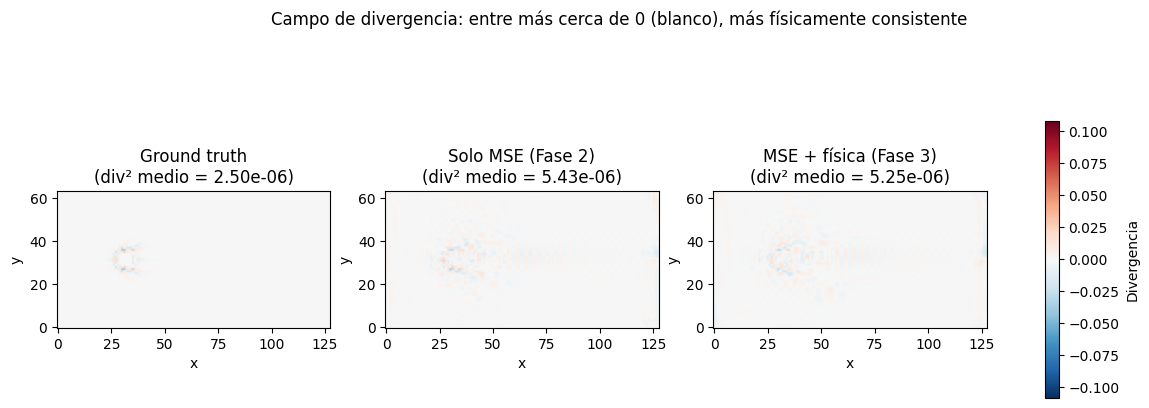

In [ ]:
def compute_divergence_field(ux, uy, dx=1.0, dy=1.0):
    dudx = np.gradient(ux, dx, axis=1)
    dvdy = np.gradient(uy, dy, axis=0)
    return dudx + dvdy

sample_idx = 0
lr_sample, hr_sample = test_ds[sample_idx]
lr_sample_b = lr_sample.unsqueeze(0).to(device)

with torch.no_grad():
    pred_mse_sample  = mse_only_model(lr_sample_b).cpu().squeeze(0)
    pred_phys_sample = physics_model(lr_sample_b).cpu().squeeze(0)

def denorm_np(x):
    return x.numpy() * std_hr[0] + mean_hr[0]

hr_phys_np   = denorm_np(hr_sample)
mse_phys_np  = denorm_np(pred_mse_sample)
phys_phys_np = denorm_np(pred_phys_sample)

div_true = compute_divergence_field(hr_phys_np[0], hr_phys_np[1])
div_mse  = compute_divergence_field(mse_phys_np[0], mse_phys_np[1])
div_phys = compute_divergence_field(phys_phys_np[0], phys_phys_np[1])

vmax = np.abs(div_true).max() * 3  # escala generosa para que ambos paneles sean comparables

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
titles = ['Ground truth', 'Solo MSE (Fase 2)', 'MSE + física (Fase 3)']
fields = [div_true, div_mse, div_phys]
for ax, field, title in zip(axes, fields, titles):
    im = ax.imshow(field, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'{title}\n(div² medio = {np.mean(field**2):.2e})')
    ax.set_xlabel('x'); ax.set_ylabel('y')
fig.colorbar(im, ax=axes, shrink=0.8, label='Divergencia')
plt.suptitle('Campo de divergencia: entre más cerca de 0 (blanco), más físicamente consistente', y=1.05)
plt.show()

## 6. Guardar el modelo con física

In [ ]:
torch.save({
    'model_state_dict': physics_model.state_dict(),
    'mean_hr': mean_hr, 'std_hr': std_hr,
    'mean_lr': mean_lr, 'std_lr': std_lr,
    'lambda_div': LAMBDA_DIV,
    'n_epochs': N_EPOCHS,
    'final_l2_error': np.mean(l2_physics),
    'final_divergence': np.mean(div_physics),
}, os.path.join(MODEL_DIR, 'srcnn_physics_cylinder_wake.pt'))

print('Modelo guardado en:', os.path.join(MODEL_DIR, 'srcnn_physics_cylinder_wake.pt'))

Modelo guardado en: /content/drive/MyDrive/proyecto_fluidos/modelos/srcnn_physics_cylinder_wake.pt


## 7. Cómo interpretar tus resultados (y próximos pasos)

Tres escenarios posibles al comparar Fase 2 vs. Fase 3:

- **Divergencia baja notablemente, L2 se mantiene similar:** el mejor resultado posible -- ganaste consistencia física casi gratis. Repórtalo así en el README, es el punto más fuerte de tu proyecto.
- **Divergencia baja, pero L2 empeora notablemente:** `LAMBDA_DIV` está muy alto -- el modelo está sacrificando precisión por suavidad. Baja `LAMBDA_DIV` (prueba 0.01 o 0.05) y reentrena.
- **Divergencia casi no cambia:** `LAMBDA_DIV` está muy bajo, o el learning rate no le da suficiente peso al gradiente de la física frente al de MSE. Sube `LAMBDA_DIV` (prueba 0.5 o 1.0).

**Siguientes fases pendientes (de tu plan original):**
1. ~~Penalización física por divergencia~~ ✅ (esta fase)
2. **Comparación con GAN** -- mismo dataset, pero con un discriminador, para ver si captura mejor las escalas pequeñas (a costa de menos garantías físicas).
3. **Generalización a otro Reynolds** -- entrenar a un Re y evaluar en otro, para probar si el modelo aprendió física o memorizó el patrón.
4. **Documentación completa en GitHub** -- README con motivación, arquitecturas, todas las imágenes generadas, tabla comparativa de las 3 fases, y cita a Fukami, Fukagata & Taira (2019).

Dime qué números te salieron (L2 y divergencia, fases 2 vs 3) y seguimos con la GAN o con la generalización de Reynolds, lo que prefieras.